## Libraries and Packages

In [1]:
import cv2
import matplotlib.pyplot as plt
import numpy as np

**Dense optical flow**

Dense optical flow is a computer vision technique that calculates the motion vectors for every pixel in a sequence of images, providing a comprehensive motion field for the entire frame. Unlike sparse methods that track only select points, dense optical flow analyzes the motion of every pixel, making it valuable for applications requiring detailed motion analysis.

It computes the motion of each pixel between consecutive frames, unlike sparse methods that only track a few selected points.

The result is a dense flow field, representing the motion of every pixel, which provides a more complete understanding of the scene's dynamics.

## Variables and Video

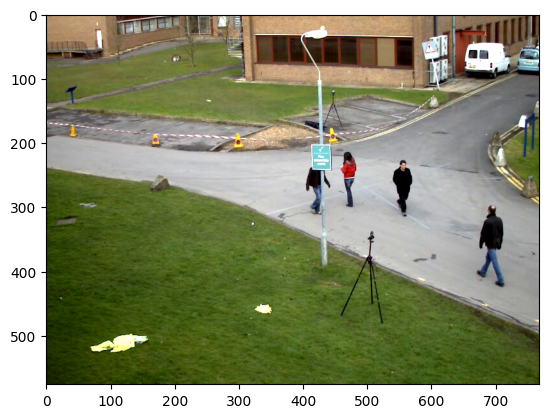

In [2]:
cap = cv2.VideoCapture('videos/vtest.avi')

while True:
    ret, frame = cap.read()
    
    if not ret:
        print("Exiting ...")
        break
    cv2.imshow('video', frame)
    if cv2.waitKey(1) & 0xFF == 27:
        plt.imshow(frame[...,::-1])
        break

cap.release()
cv2.destroyAllWindows()

In [6]:
farneback_features = dict( pyr_scale = 0.5, 
                           levels= 3, 
                           winsize = 15, 
                           iterations = 3, 
                           poly_n = 5, 
                           poly_sigma = 1.2, 
                           flags=0)

In [4]:
cap = cv2.VideoCapture('videos/vtest.avi')
#read the first frame of video
ret, frame = cap.read()
old_frame = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
hsv = np.zeros_like(frame)
hsv[..., 1] = 255

## FarneBack algorithm

In [8]:
while True:
    #Lets read frames from second frame(we have used the first one!)
    ret, frame = cap.read()
    if not ret:
        print('Exiting ...')
        break
    #Convert new frame to grayscale for FarneBack algorithm
    new_frame = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
    #lets calculate the flow
    flow = cv2.calcOpticalFlowFarneback(old_frame, new_frame, None, **farneback_features)
    #we have magnitude of changes and their angles for each point
    mag, ang = cv2.cartToPolar(flow[..., 0], flow[..., 1])
    #lets calculate the hue for angle demonstration of motions
    hsv[..., 0] = ang*180/np.pi/2
    #lets copy a normalized form of magnitudes between 0 to 255 for our color's value
    hsv[..., 2] = cv2.normalize(mag, None, 0, 255, cv2.NORM_MINMAX)
    #make the frame BGR for demonstration
    bgr = cv2.cvtColor(hsv, cv2.COLOR_HSV2BGR)
    cv2.imshow('frame', bgr)
    k = cv2.waitKey(30) & 0xff
    if k == 27:
        break
    elif k == ord('s'):
        cv2.imwrite('opticalfb.png', frame)
        cv2.imwrite('opticalhsv.png', bgr)
    old_frame = new_frame
cv2.destroyAllWindows()